In [1]:
import pandas as pd
import numpy as np
from scipy.stats import wasserstein_distance

In [2]:
def compute_ister_score(dataset_df, user_info_df):
    merged_df = pd.merge(dataset_df, user_info_df, left_on="user_id", right_on="user_id")
    item_attr_interactions_df = merged_df[["item_id", "attr"]]
    item_attr_dist = item_attr_interactions_df.groupby(["item_id", "attr"]).size()
    attr_dist = item_attr_interactions_df.groupby("attr").size()
    igi_score = item_attr_dist / attr_dist
    
    # compute i_ster score
    ister_scores = dict()
    for iid in dataset_df["item_id"].unique():
        if 0 not in igi_score.loc[iid] or 1 not in igi_score.loc[iid]:
            ister_scores[iid] = 0
        else:
            diff = igi_score.loc[iid][0] - igi_score.loc[iid][1]
            ister_scores[iid] = diff / max(igi_score.loc[iid][0], igi_score.loc[iid][1])
    
    return ister_scores

def measure_stereotypicality(user_stereotypicality, attr):
    if attr == 0:
        return user_stereotypicality
    else:
        return -user_stereotypicality

In [3]:
dataset_df = pd.read_csv("ambar/ambar.dataset.rating", sep="\t", header=None, names=["user_id", "item_id", "rating"])

users_df = pd.read_csv("ambar/ambar.userlist", sep="\t")
users_df.columns = ["user_id", "attr"]

ister_scores = compute_ister_score(dataset_df, users_df)
dataset_df["i_ster"] = dataset_df["item_id"].map(ister_scores)

uster_scores = dataset_df.groupby("user_id")["i_ster"].mean()
users_df["u_ster"] = users_df["user_id"].map(uster_scores)

users_df["abs_u_ster"] = users_df.apply(lambda r: measure_stereotypicality(r["u_ster"], r["attr"]), axis=1)

# user analysis

In [4]:
users_df.groupby("attr")["u_ster"].mean()

attr
0    0.052656
1   -0.033669
Name: u_ster, dtype: float64

attr
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
Name: u_ster, dtype: object

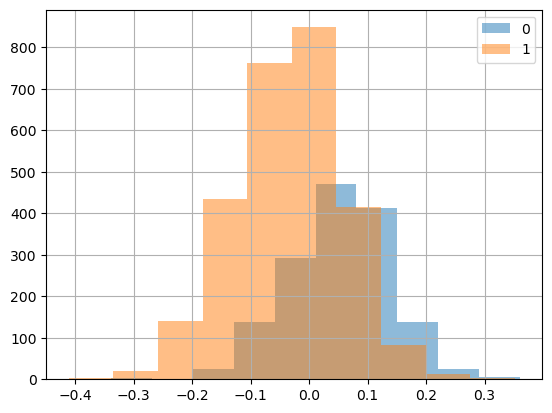

In [5]:
users_df.groupby("attr")["u_ster"].hist(alpha=.5, legend=True)

In [6]:
users_df["attr"].value_counts() / len(users_df)

1    0.643094
0    0.356906
Name: attr, dtype: float64

In [7]:
df = dataset_df.merge(users_df, left_on="user_id", right_on="user_id")
print((df[df["attr"] == 0]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x > 0).mean())
print((df[df["attr"] == 1]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x < 0).mean())

x = (df[df["attr"] == 0]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x > 0).sum()
y = (df[df["attr"] == 1]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x < 0).sum()

(x+y) / df["user_id"].nunique()

0.58630559225011
0.5426223341146511


34.77223273415326

In [8]:
users_df["abs_u_ster"].mean()

0.0404456269990727

In [9]:
u_ster0 = users_df[users_df["attr"] == 0]["u_ster"].values
u_ster1 = users_df[users_df["attr"] == 1]["u_ster"].values
wasserstein_distance(u_ster0, u_ster1)

0.08632523179448744

## select only stereotypical users

0.7415506958250497
0.6296432511952924
0.6695837275307474
attr
0    0.090507
1   -0.088271
Name: u_ster, dtype: float64
1    0.604733
0    0.395267
Name: attr, dtype: float64
0.6515761848088132
0.621780361491237
0.08915513930139883


attr
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
Name: u_ster, dtype: object

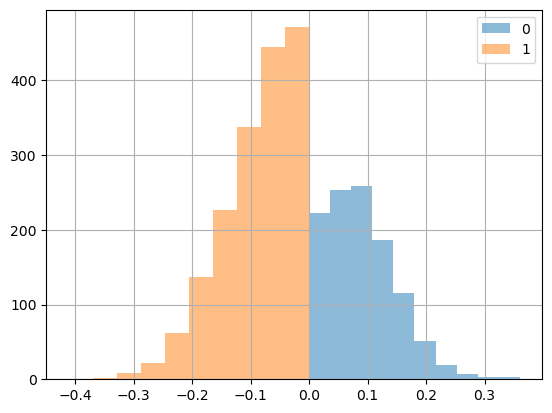

In [10]:
users0_df = users_df[(users_df["attr"] == 0) & (users_df["u_ster"] > 0)]
users1_df = users_df[(users_df["attr"] == 1) & (users_df["u_ster"] < 0)]

print(len(users0_df) / (users_df["attr"] == 0).sum())
print(len(users1_df) / (users_df["attr"] == 1).sum())

stereotypical_users_df = pd.concat([users0_df, users1_df])
print(len(stereotypical_users_df) / len(users_df))

print(stereotypical_users_df.groupby("attr")["u_ster"].mean())
print(stereotypical_users_df["attr"].value_counts() / len(stereotypical_users_df))

df = dataset_df.merge(stereotypical_users_df, left_on="user_id", right_on="user_id")
print((df[df["attr"] == 0]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x > 0).mean())
print((df[df["attr"] == 1]).groupby("user_id", group_keys=False)["i_ster"].apply(lambda x: x < 0).mean())

print(stereotypical_users_df["abs_u_ster"].mean())
stereotypical_users_df.groupby("attr")["u_ster"].hist(alpha=.5, legend=True)

In [11]:
print(len(stereotypical_users_df) / len(users_df))
stereotypical_users_df["abs_u_ster"].mean()

0.6695837275307474


0.08915513930139883

In [12]:
users0_df = users_df[(users_df["attr"] == 0) & (users_df["u_ster"] < 0)]
users1_df = users_df[(users_df["attr"] == 1) & (users_df["u_ster"] > 0)]

antistereotypical_users_df = pd.concat([users0_df, users1_df])
print(len(antistereotypical_users_df) / len(users_df))
print(antistereotypical_users_df.groupby("attr")["u_ster"].mean())
print(antistereotypical_users_df["abs_u_ster"].mean())

0.3304162724692526
attr
0   -0.055946
1    0.059161
Name: u_ster, dtype: float64
-0.058263484903493694


In [13]:
n = int(np.ceil(0.25 * len(users_df)))
top_steretypical_users_df = users_df.sort_values(by="abs_u_ster", ascending=False).head(n)

top_steretypical_users_df.groupby("attr").size()

attr
0    432
1    625
dtype: int64

In [35]:
stereotypical_users_df = users_df[users_df["abs_u_ster"] > 0.1]

In [36]:
stereotypical_users = stereotypical_users_df["user_id"].values
stereotypical_df = df[df["user_id"].isin(stereotypical_users)]

user_map = {old: new for new, old in enumerate(stereotypical_df["user_id"].unique())}
item_map = {old: new for new, old in enumerate(stereotypical_df["item_id"].unique())}

stereotypical_df["user_id"] = stereotypical_df["user_id"].map(user_map)
stereotypical_df["item_id"] = stereotypical_df["item_id"].map(item_map)
stereotypical_df.rename(columns={"user_id": "user_id:token", "item_id": "item_id:token", "rating": "rating:token", "attr": "attr:token"}, inplace=True)

stereotypical_df[["user_id:token", "item_id:token", "rating:token"]].to_csv("ambar.dataset.rating", sep="\t", index=False, header=False)
stereotypical_df.drop_duplicates(subset=["user_id:token", "attr:token"]).to_csv("ambar.userlist", sep="\t", index=False)

C:\Users\pmuellner\AppData\Local\Temp\ipykernel_14992\2050501277.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stereotypical_df["user_id"] = stereotypical_df["user_id"].map(user_map)
C:\Users\pmuellner\AppData\Local\Temp\ipykernel_14992\2050501277.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stereotypical_df["item_id"] = stereotypical_df["item_id"].map(item_map)
C:\Users\pmuellner\AppData\Local\Temp\ipykernel_14992\2050501277.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy 

# item analysis

In [51]:
items0 = dict()
items1 = dict()
for iid, score in ister_scores.items():
    if score > 0:
        items0[iid] = score
    elif score < 0:
        items1[iid] = score

print(len(items0) / len(ister_scores), len(items1) / len(ister_scores))
print(np.mean(list(items0.values())), np.mean(list(items1.values())))

0.49925410243659873 0.49925410243659873
0.2466250950403157 -0.2754624921543081
